## 📋 Proyecto: SmartBank 📋
### Análisis de efectividad de una campaña de marketing directo en una entidad financiera para captación de inversiones a plazo fijo.

Desarrollado por: Gabriel Parrales Gutiérrez


## 🗂️  Importar las librerías y leer los archivos necesarios

In [ ]:
# Librerías
# Escribe tu código aquí ⤵️

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Archivos

df = pd.read_csv('BankCampaign.csv', sep = ',')


## 1️⃣ Exploración inicial del dataset 🔍

Leer el archivo y examinar sus dimensiones. Identificar las columnas disponibles y los tipos de datos que contiene.


In [ ]:
# Escribe tu código aquí ⤵️

df.head(10)

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261.0,1,999,0,nonexistent,no
1,1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,149.0,1,999,0,nonexistent,no
2,2,37.0,NaN,married,high.school,no,yes,no,telephone,may,mon,226.0,1,999,0,nonexistent,no
3,3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,151.0,1,999,0,nonexistent,no
4,4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,307.0,1,999,0,nonexistent,no
5,5,45.0,services,married,basic.9y,unknown,no,no,telephone,may,mon,198.0,1,999,0,nonexistent,no
6,6,59.0,admin.,married,professional.course,no,no,no,telephone,may,mon,139.0,1,999,0,nonexistent,no
7,7,41.0,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217.0,1,999,0,nonexistent,no
8,8,24.0,technician,single,professional.course,no,yes,no,telephone,may,mon,380.0,1,999,0,nonexistent,no
9,9,25.0,services,single,high.school,no,yes,no,telephone,may,mon,50.0,1,999,0,nonexistent,no


In [ ]:
# Escribe tu código aquí ⤵️

print('La cantidad de registros es: ', df.shape[0])
print('La cantidad de variables es: ', df.shape[1])

La cantidad de registros es:  41188
La cantidad de variables es:  17


In [ ]:
# Descripción del tipo de datos de las variables del dataset.
# Escribe tu código aquí ⤵️

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   41188 non-null  int64  
 1   age          40612 non-null  float64
 2   job          39088 non-null  object 
 3   marital      41188 non-null  object 
 4   education    39912 non-null  object 
 5   default      41188 non-null  object 
 6   housing      41188 non-null  object 
 7   loan         41188 non-null  object 
 8   contact      41188 non-null  object 
 9   month        41188 non-null  object 
 10  day_of_week  41188 non-null  object 
 11  duration     40324 non-null  float64
 12  campaign     41188 non-null  int64  
 13  pdays        41188 non-null  int64  
 14  previous     41188 non-null  int64  
 15  poutcome     41188 non-null  object 
 16  y            41188 non-null  object 
dtypes: float64(2), int64(4), object(11)
memory usage: 5.3+ MB


In [ ]:
# Estadísticas descriptivas de las variables numéricas.
# Escribe tu código aquí ⤵️

df.describe()

,Unnamed: 0,age,duration,campaign,pdays,previous
count,41188.00000,40612.000000,40324.000000,41188.000000,41188.000000,41188.000000
mean,20593.50000,40.018320,258.538959,2.567593,962.475454,0.172963
std,11890.09578,10.416538,259.439277,2.770014,186.910907,0.494901
min,0.00000,17.000000,0.000000,1.000000,0.000000,0.000000
25%,10296.75000,32.000000,103.000000,1.000000,999.000000,0.000000
50%,20593.50000,38.000000,180.000000,2.000000,999.000000,0.000000
75%,30890.25000,47.000000,320.000000,3.000000,999.000000,0.000000
max,41187.00000,98.000000,4918.000000,56.000000,999.000000,7.000000


In [ ]:
# Valores únicos de variables categóricas.
# Escribe tu código aquí ⤵️

print(df['job'].unique())
print(df['marital'].unique())
print(df['education'].unique())
print(df['default'].unique())
print(df['housing'].unique())
print(df['loan'].unique())
print(df['contact'].unique())
print(df['month'].unique())
print(df['day_of_week'].unique())
print(df['poutcome'].unique())

['housemaid' 'services' nan 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
['married' 'single' 'divorced' 'unknown']
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' nan 'illiterate']
['no' 'unknown' 'yes']
['no' 'yes' 'unknown']
['no' 'yes' 'unknown']
['telephone' 'cellular']
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
['mon' 'tue' 'wed' 'thu' 'fri']
['nonexistent' 'failure' 'success']


## 2️⃣ Evaluación de calidad de datos 🛠️
Este proceso consiste en la eliminación de datos nulos y/o faltantes, análisis exploratorio de datos, identificación de outliers y el tratamiento de los mismos.

Determinar la existencia de registros duplicados e identificar columnas con valores faltantes o nulos.

In [ ]:
# Comprobación de registros duplicados
# Escribe tu código aquí ⤵️

duplicados = df.duplicated().sum()
print('Existen ', duplicados, ' registros duplicados')

# Comprobación de valores faltantes y/o nulos
df.isna().sum()

Existen  0  registros duplicados


,0
Unnamed: 0,0
age,576
job,2100
marital,0
education,1276
default,0
housing,0
loan,0
contact,0
month,0


In [ ]:
# Se realiza una copia del dataframe original y se eliminarán los datos nulos
# de todas las variables para determinar el porcentaje de datos correspondiente.
# Escribe tu código aquí ⤵️

df_original = df.copy()
df.dropna(subset = ['age', 'job', 'education', 'duration'], inplace = True)

cant_datos = df.shape[0]
cant_datos_original = df_original.shape[0]
porcentaje_nulos = round(100 - (cant_datos / cant_datos_original) * 100,2)
print('El porcentaje de datos nulos de todas las variables es: ',porcentaje_nulos,'%')

El porcentaje de datos nulos de todas las variables es:  11.2 %


In [ ]:
# Se verifica la NO existencia de datos nulos.
# Escribe tu código aquí ⤵️

df.isna().sum()


,0
Unnamed: 0,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0


Segmentar el dataset con los registros de aquellos clientes que aceptaron realizar "Inversiones a plazo fijo"

In [ ]:
# Se realiza la segmentación y se crean dataset separados
# Escribe tu código aquí ⤵️

df_si = df[df['y'] == 'yes'].copy()
df_no = df[df['y'] == 'no'].copy()
total_si = df_si.shape[0]
total_no = df_no.shape[0]
total_registros = df.shape[0]
print('La cantidad de registros con respuesta "Sí" es: ', df_si.shape[0])
print('La cantidad de registros con respuesta "No" es: ', df_no.shape[0])
print('Los clientes que SI aceptaron la inversión a plazo fijo representan el ',round((total_si/total_registros)*100,2),'%')
print('Los clientes que NO aceptaron la inversión a plazo fijo representan el ',round((total_no/total_registros)*100,2),'%')

La cantidad de registros con respuesta "Sí" es:  4115
La cantidad de registros con respuesta "No" es:  32461
Los clientes que SI aceptaron la inversión a plazo fijo representan el  11.25 %
Los clientes que NO aceptaron la inversión a plazo fijo representan el  88.75 %


<Axes: title={'center': 'Aceptación del producto'}>

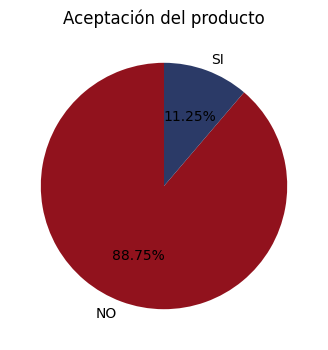

In [ ]:
# Gráfico para establecer visualmente la segmentación
# Escribe tu código aquí ⤵️

df['y'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%',
    colors=['#91121D', '#2B3A67'],
    startangle=90,
    figsize=(6,4),
    labels=['NO', 'SI'],
    title='Aceptación del producto',
    ylabel = '' )

📚 **Análisis de outliers en la variable "Edad"**

Esta variable representa la edad de las personas investigadas.

In [ ]:
# Calculo de cuartiles, rangos y porcentaje de outliers
# Escribe tu código aquí ⤵️

Q1 = df_si['age'].quantile(0.25)
Q2 = df_si['age'].quantile(0.50)
Q3 = df_si['age'].quantile(0.75)

print('Quartil 1: ', Q1)
print('Quartil 2: ', Q2)
print('Quartil 3: ', Q3)

RIC = Q3 - Q1
print('El rango intercuartílico de la variable "Edad" es: ', RIC)

# Limites inferior y superior
lim_inferior = Q1 - 1.5 * RIC
lim_superior = Q3 + 1.5 * RIC

print('El límite inferior de las edades es: ', lim_inferior)
print('El límite superior de las edades es: ', lim_superior)

cant_out_inferior = df_si[df_si['age'] < lim_inferior].shape[0]
print('La cantidad de outliers por debajo del límite inferior es: ', cant_out_inferior)

cant_out_superior = df_si[df_si['age'] > lim_superior].shape[0]
print('La cantidad de outliers por encima del límite superior es: ', cant_out_superior)

porc_outliers = (cant_out_inferior + cant_out_superior) / df_si.shape[0]
print('El total de outliers representa el', round(100*porc_outliers,2), '% del total de los datos')

cota_outliers = df_si['age'].quantile(1-round(porc_outliers,4))
print ('Los outliers se presentan a edades superiores a los ', cota_outliers, 'años')

Quartil 1:  31.0
Quartil 2:  37.0
Quartil 3:  50.0
El rango intercuartílico de la variable "Edad" es:  19.0
El límite inferior de las edades es:  2.5
El límite superior de las edades es:  78.5
La cantidad de outliers por debajo del límite inferior es:  0
La cantidad de outliers por encima del límite superior es:  72
El total de outliers representa el 1.75 % del total de los datos
Los outliers se presentan a edades superiores a los  78.00500000000011 años


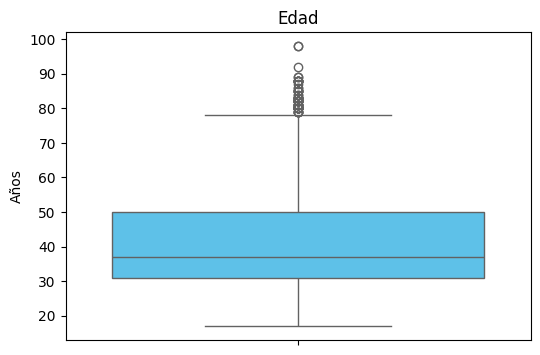

In [ ]:
# Boxplot de la variable age
# Escribe tu código aquí ⤵️

plt.figure(figsize=(6, 4))
sns.boxplot(y = df_si['age'], color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Edad')
plt.ylabel('Años')
plt.show()

📚 **Análisis de outliers en la variable "duration"**

Esta variable se refiere a la duración de la llamada de la última interacción, se mide en segundos y sólo es conocida una vez terminada la llamada.

In [ ]:
# Calculo de cuartiles, rangos y porcentaje de outliers
# Escribe tu código aquí ⤵️

Q1 = df_si['duration'].quantile(0.25)
Q2 = df_si['duration'].quantile(0.50)
Q3 = df_si['duration'].quantile(0.75)

print('Quartil 1: ', Q1)
print('Quartil 2: ', Q2)
print('Quartil 3: ', Q3)

RIC = Q3 - Q1
print('El rango intercuartílico de la variable "duration" es: ', RIC)

# Limites inferior y superior
lim_inferior = Q1 - 1.5 * RIC
lim_superior = Q3 + 1.5 * RIC

print('El límite inferior de las edades es: ', lim_inferior)
print('El límite superior de las edades es: ', lim_superior)

cant_out_inferior = df_si[df_si['duration'] < lim_inferior].shape[0]
print('La cantidad de outliers por debajo del límite inferior es: ', cant_out_inferior)

cant_out_superior = df_si[df_si['duration'] > lim_superior].shape[0]
print('La cantidad de outliers por encima del límite superior es: ', cant_out_superior)

porc_outliers = (cant_out_inferior + cant_out_superior) / df_si.shape[0]
print('El total de outliers representa el', round(100*porc_outliers,2), '% del total de los datos')

cota_outliers = df_si['duration'].quantile(1-round(porc_outliers,4))
print ('Los outliers se presentan a llamadas superiores a los ', cota_outliers, 'segundos')

Quartil 1:  253.0
Quartil 2:  445.0
Quartil 3:  738.5
El rango intercuartílico de la variable "duration" es:  485.5
El límite inferior de las edades es:  -475.25
El límite superior de las edades es:  1466.75
La cantidad de outliers por debajo del límite inferior es:  0
La cantidad de outliers por encima del límite superior es:  124
El total de outliers representa el 3.01 % del total de los datos
Los outliers se presentan a llamadas superiores a los  1463.6743999999999 segundos


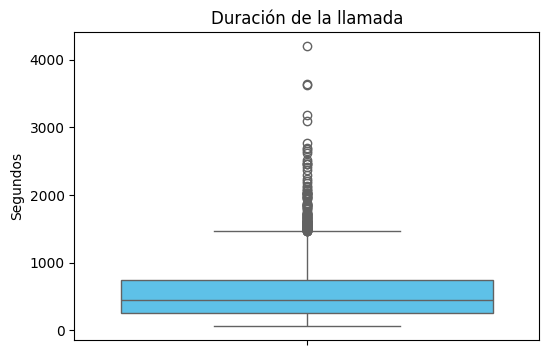

In [ ]:
# Boxplot de la variable duration
# Escribe tu código aquí ⤵️

plt.figure(figsize=(6, 4))
sns.boxplot(y = df_si['duration'], color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Duración de la llamada')
plt.ylabel('Segundos')
plt.show()

📚 **Análisis de outliers en la variable "Campaign"**

Esta variable se refiere a la cantidad de contactos realizados durante esta campaña y para este cliente (incluye el último contacto).

In [ ]:
# Calculo de cuartiles, rangos y porcentaje de outliers
# Escribe tu código aquí ⤵️

Q1 = df_si['campaign'].quantile(0.25)
Q2 = df_si['campaign'].quantile(0.50)
Q3 = df_si['campaign'].quantile(0.75)

print('Quartil 1: ', Q1)
print('Quartil 2: ', Q2)
print('Quartil 3: ', Q3)

RIC = Q3 - Q1
print('El rango intercuartílico de la variable "campaign" es: ', RIC)

# Limites inferior y superior
lim_inferior = Q1 - 1.5 * RIC
lim_superior = Q3 + 1.5 * RIC

print('El límite inferior de la cantidad de contactos es: ', lim_inferior)
print('El límite superior de la cantidad de contactos es: ', lim_superior)

cant_out_inferior = df_si[df_si['campaign'] < lim_inferior].shape[0]
print('La cantidad de outliers por debajo del límite inferior es: ', cant_out_inferior)

cant_out_superior = df_si[df_si['campaign'] > lim_superior].shape[0]
print('La cantidad de outliers por encima del límite superior es: ', cant_out_superior)

porc_outliers = (cant_out_inferior + cant_out_superior) / df_si.shape[0]
print('El total de outliers representa el', round(100*porc_outliers,2), '% del total de los datos')

cota_outliers = df_si['campaign'].quantile(1-round(porc_outliers,4))
print ('Los outliers se presentan a partir de los ', cota_outliers, 'interacciones')

Quartil 1:  1.0
Quartil 2:  2.0
Quartil 3:  2.0
El rango intercuartílico de la variable "campaign" es:  1.0
El límite inferior de la cantidad de contactos es:  -0.5
El límite superior de la cantidad de contactos es:  3.5
La cantidad de outliers por debajo del límite inferior es:  0
La cantidad de outliers por encima del límite superior es:  492
El total de outliers representa el 11.96 % del total de los datos
Los outliers se presentan a partir de los  3.0 interacciones


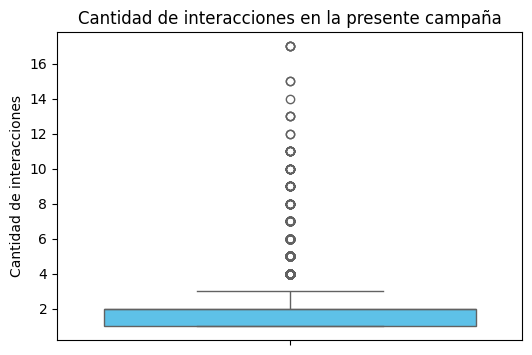

In [ ]:
# Boxplot de la variable duration
# Escribe tu código aquí ⤵️

plt.figure(figsize=(6, 4))
sns.boxplot(y = df_si['campaign'], color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Cantidad de interacciones en la presente campaña')
plt.ylabel('Cantidad de interacciones')
plt.show()

📚 **Análisis de outliers en la variable "pdays"**

Esta variable representa la cantidad de días transcurridos desde el último contacto con el cliente en una campaña anterior (el valor "999" significa que no se contactó previamente con el cliente).

In [ ]:
# Escribe tu código aquí ⤵️
# Construcción de frecuencias para determinar la distribución de los datos
df_pdays = df_si['pdays'].value_counts().sort_index()
df_pdays = df_pdays.reset_index()
df_pdays.columns = ['pdays', 'frecuencia']
df_pdays


,pdays,frecuencia
0,0,8
1,1,7
2,2,33
3,3,267
4,4,52
5,5,28
6,6,266
7,7,33
8,8,12
9,9,30


In [ ]:
# Calculamos el porcentaje de datos que representa el valor "999"
# Escribe tu código aquí ⤵️

sin_contacto_previo = df_si[df_si['pdays'] == 999].shape[0]
porcentaje_scp = round(100 * sin_contacto_previo / df_si.shape[0],2)
print('La cantidad de clientes que no han sido contactados previo a la presente campaña es: ', sin_contacto_previo)
print('Esto representa el', porcentaje_scp, '% del total de los datos')

La cantidad de clientes que no han sido contactados previo a la presente campaña es:  3246
Esto representa el 78.88 % del total de los datos


In [ ]:
# Eliminamos aquellos registros con valor "999"
# Escribe tu código aquí ⤵️

df_temp = df_si[df_si['pdays'] != 999].copy()

# Calculo de cuartiles, rangos y porcentaje de outliers


Q1 = df_temp['pdays'].quantile(0.25)
Q2 = df_temp['pdays'].quantile(0.50)
Q3 = df_temp['pdays'].quantile(0.75)

print('Quartil 1: ', Q1)
print('Quartil 2: ', Q2)
print('Quartil 3: ', Q3)

RIC = Q3 - Q1
print('El rango intercuartílico de la variable "pdays" es: ', RIC)

# Limites inferior y superior
lim_inferior = Q1 - 1.5 * RIC
lim_superior = Q3 + 1.5 * RIC

print('El límite inferior de la cantidad de días desde el último contacto es: ', lim_inferior)
print('El límite superior de la cantidad de días desde el último contacto es: ', lim_superior)

cant_out_inferior = df_temp[df_temp['pdays'] < lim_inferior].shape[0]
print('La cantidad de outliers por debajo del límite inferior es: ', cant_out_inferior)

cant_out_superior = df_temp[df_temp['pdays'] > lim_superior].shape[0]
print('La cantidad de outliers por encima del límite superior es: ', cant_out_superior)

porc_outliers = (cant_out_inferior + cant_out_superior) / df_temp.shape[0]
print('El total de outliers representa el', round(100*porc_outliers,2), '% del total de los datos')

cota_outliers = df_temp['pdays'].quantile(1-round(porc_outliers,4))
print ('Los outliers se presentan a partir de los ', cota_outliers, 'días')

Quartil 1:  3.0
Quartil 2:  6.0
Quartil 3:  6.0
El rango intercuartílico de la variable "pdays" es:  3.0
El límite inferior de la cantidad de días desde el último contacto es:  -1.5
El límite superior de la cantidad de días desde el último contacto es:  10.5
La cantidad de outliers por debajo del límite inferior es:  0
La cantidad de outliers por encima del límite superior es:  107
El total de outliers representa el 12.31 % del total de los datos
Los outliers se presentan a partir de los  10.149200000000064 días


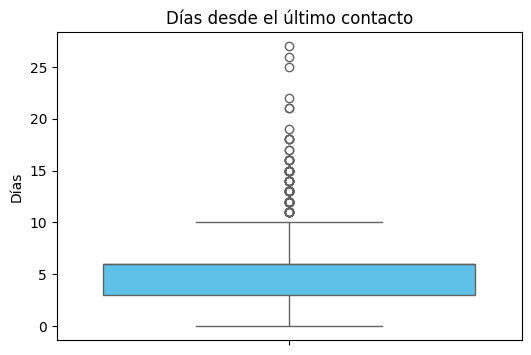

In [ ]:
# Boxplot de la variable duration
# Escribe tu código aquí ⤵️

plt.figure(figsize=(6, 4))
sns.boxplot(y = df_temp['pdays'], color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Días desde el último contacto')
plt.ylabel('Días')
plt.show()

📚 **Análisis de outliers en la variable "previous"**

Esta variable se refiere a la cantidad total de contactos realizados antes de la campaña actual.

In [ ]:
# Calculo de cuartiles, rangos y porcentaje de outliers
# Escribe tu código aquí ⤵️

Q1 = df_si['previous'].quantile(0.25)
Q2 = df_si['previous'].quantile(0.50)
Q3 = df_si['previous'].quantile(0.75)

print('Quartil 1: ', Q1)
print('Quartil 2: ', Q2)
print('Quartil 3: ', Q3)

RIC = Q3 - Q1
print('El rango intercuartílico de la variable "campaign" es: ', RIC)

# Limites inferior y superior
lim_inferior = Q1 - 1.5 * RIC
lim_superior = Q3 + 1.5 * RIC

print('El límite inferior de la cantidad de interacciones previas a esta camapaña es: ', lim_inferior)
print('El límite superior de la cantidad de interacciones previas a esta camapaña es: ', lim_superior)

cant_out_inferior = df_si[df_si['previous'] < lim_inferior].shape[0]
print('La cantidad de outliers por debajo del límite inferior es: ', cant_out_inferior)

cant_out_superior = df_si[df_si['previous'] > lim_superior].shape[0]
print('La cantidad de outliers por encima del límite superior es: ', cant_out_superior)

porc_outliers = (cant_out_inferior + cant_out_superior) / df_si.shape[0]
print('El total de outliers representa el', round(100*porc_outliers,2), '% del total de los datos')

cota_outliers = df_si['previous'].quantile(1-round(porc_outliers,4))
print ('Los outliers se presentan a partir de las ', cota_outliers, 'interacciones previas a esta camapaña')

Quartil 1:  0.0
Quartil 2:  0.0
Quartil 3:  1.0
El rango intercuartílico de la variable "campaign" es:  1.0
El límite inferior de la cantidad de interacciones previas a esta camapaña es:  -1.5
El límite superior de la cantidad de interacciones previas a esta camapaña es:  2.5
La cantidad de outliers por debajo del límite inferior es:  0
La cantidad de outliers por encima del límite superior es:  160
El total de outliers representa el 3.89 % del total de los datos
Los outliers se presentan a partir de las  2.0 interacciones previas a esta camapaña


In [ ]:
# Escribe tu código aquí ⤵️
# Construcción de frecuencias para determinar la distribución de los datos
df_previous = df_si['previous'].value_counts().sort_index()
df_previous = df_previous.reset_index()
df_previous.columns = ['previous', 'frecuencia']
df_previous

,previous,frecuencia
0,0,2769
1,1,865
2,2,321
3,3,115
4,4,31
5,5,12
6,6,2


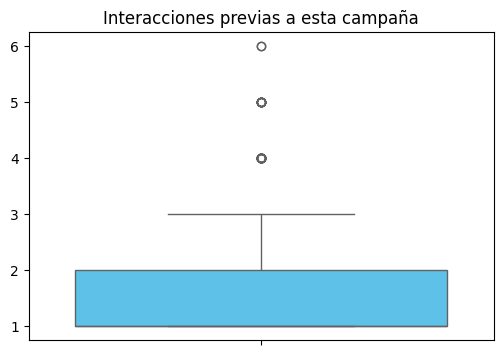

In [ ]:
# Boxplot de la variable duration
# Escribe tu código aquí ⤵️

plt.figure(figsize=(6, 4))
sns.boxplot(y = df_temp['previous'], color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Interacciones previas a esta campaña')
plt.ylabel('')
plt.show()

##3️⃣ Imputación de datos
En este proceso se busca determinar el mejor tratamiento de los outliers encontrados.

❌ Eliminación de outliers

In [ ]:
# Se eliminan todos los outliers
# Escribe tu código aquí ⤵️

df_sin_outliers = df_si[
    (df_si['age'] < 78) &
    (df_si['duration'] < 1463) &
    (df_si['campaign'] < 3) &
    (df_si['pdays'].isin([0,1,2,3,4,5,6,7,8,9,999])) &
    (df_si['previous'] < 2)
].copy()

print('El dataset original contiene ', cant_datos_original, 'registros')
print('El dataset sin valores nulos/faltantes contiene ', cant_datos, 'registros')

total_si = df_si.shape[0]
print ('El dataset de aquellos clientes que aceptaron la inversión a plazo fijo contiene ', total_si, 'registros')

total_si_eliminados = df_sin_outliers.shape[0]
print ('Después de eliminar los outliers, quedan ', total_si_eliminados, 'registros')

print('Los datos, eliminando completamente los outliers, representa el: ', round((total_si_eliminados/total_si)*100,2),'%')


# --------------------------------------------------------------------------
# Eliminar todos los outliers recorta alrededor del 40% de toda la data, lo
# cual no es una tarea conveniente. Además, eliminarlos crea un conjunto de
# datos con nuevos outliers
# --------------------------------------------------------------------------


El dataset original contiene  41188 registros
El dataset sin valores nulos/faltantes contiene  36576 registros
El dataset de aquellos clientes que aceptaron la inversión a plazo fijo contiene  4115 registros
Después de eliminar los outliers, quedan  2518 registros
Los datos, eliminando completamente los outliers, representa el:  61.19 %


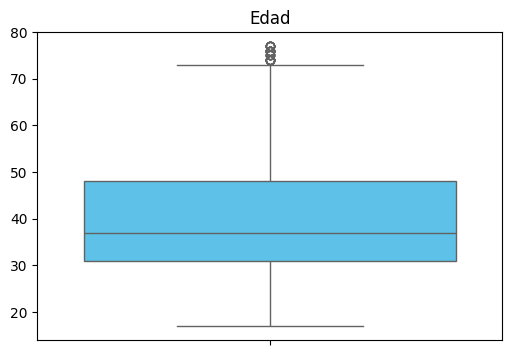

In [ ]:
# Boxplot de la variable "age"
# Escribe tu código aquí ⤵️

plt.figure(figsize=(6, 4))
sns.boxplot(y = df_sin_outliers['age'], color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Edad')
plt.ylabel('')
plt.show()

✍🏼 Capping de la variable "age"

En esta etapa se reemplazarán los outliers por el valor donde empiezan a ocurrir.

Conteo SI 14
Conteo Capping 86


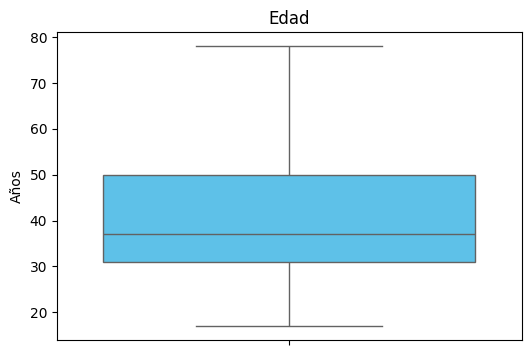

In [ ]:
# Escribe tu código aquí ⤵️

df_edad_c = df_si['age'].copy()
df_edad_c[df_edad_c >= 78] = 78

conteo1 = (df_si['age'] == 78).sum()
print('Conteo SI', conteo1)
conteo2 = (df_edad_c == 78).sum()
print('Conteo Capping', conteo2)

plt.figure(figsize=(6, 4))
sns.boxplot(y = df_edad_c, color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Edad')
plt.ylabel('Años')
plt.show()

In [ ]:
# Calculo de cuartiles, rangos y porcentaje de outliers
# Escribe tu código aquí ⤵️

df_edad_c = pd.DataFrame(df_edad_c, columns=['age'])

Q1 = df_edad_c['age'].quantile(0.25)
Q2 = df_edad_c['age'].quantile(0.50)
Q3 = df_edad_c['age'].quantile(0.75)

print('Total registros: ',df_edad_c.shape[0])
print('Quartil 1: ', Q1)
print('Quartil 2: ', Q2)
print('Quartil 3: ', Q3)
print('El promedio es:', df_edad_c['age'].mean())

RIC = Q3 - Q1
print('El rango intercuartílico de la variable "Edad" es: ', RIC)

# Limites inferior y superior
lim_inferior = Q1 - 1.5 * RIC
lim_superior = Q3 + 1.5 * RIC

print('El límite inferior de las edades es: ', lim_inferior)
print('El límite superior de las edades es: ', lim_superior)

cant_out_inferior = df_edad_c[df_edad_c['age'] < lim_inferior].shape[0]
print('La cantidad de outliers por debajo del límite inferior es: ', cant_out_inferior)

cant_out_superior = df_edad_c[df_edad_c['age'] > lim_superior].shape[0]
print('La cantidad de outliers por encima del límite superior es: ', cant_out_superior)

porc_outliers = (cant_out_inferior + cant_out_superior) / df_edad_c.shape[0]
print('El total de outliers representa el', round(100*porc_outliers,2), '% del total de los datos')

cota_outliers = df_edad_c['age'].quantile(1-round(porc_outliers,4))
print ('Los outliers se presentan a edades superiores a los ', cota_outliers, 'años')

Total registros:  4115
Quartil 1:  31.0
Quartil 2:  37.0
Quartil 3:  50.0
El promedio es: 40.839611178614824
El rango intercuartílico de la variable "Edad" es:  19.0
El límite inferior de las edades es:  2.5
El límite superior de las edades es:  78.5
La cantidad de outliers por debajo del límite inferior es:  0
La cantidad de outliers por encima del límite superior es:  0
El total de outliers representa el 0.0 % del total de los datos
Los outliers se presentan a edades superiores a los  78.0 años


🔁 Reemplazo en variable "age"

En esta variable se reemplazarán los outliers por el valor correspondiente a la mediana.

Outliers antes del reemplazo 86
Conteo antes de reemplazar los outliers por la mediana 125
Conteo después de reemplazar los outliers por la mediana 211


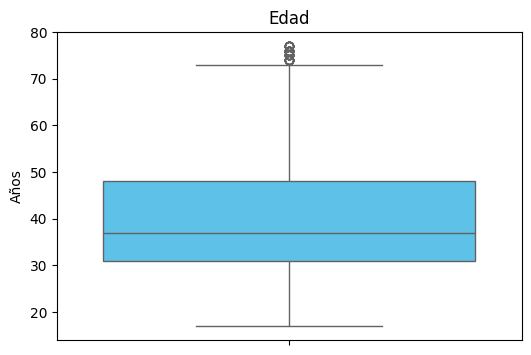

In [ ]:
# Escribe tu código aquí ⤵️

df_edad_m = df_si['age'].copy()
df_edad_m[df_edad_m >= 78] = 37

conteo1 = (df_si['age'] >= 78).sum()
print('Outliers antes del reemplazo', conteo1)
conteo2 = (df_si['age'] == 37).sum()
print('Conteo antes de reemplazar los outliers por la mediana', conteo2)
conteo3 = (df_edad_m == 37).sum()
print('Conteo después de reemplazar los outliers por la mediana', conteo3)

plt.figure(figsize=(6, 4))
sns.boxplot(y = df_edad_m, color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Edad')
plt.ylabel('Años')
plt.show()

In [ ]:
# Calculo de cuartiles, rangos y porcentaje de outliers
# Escribe tu código aquí ⤵️

df_edad_m = pd.DataFrame(df_edad_m, columns=['age'])

Q1 = df_edad_m['age'].quantile(0.25)
Q2 = df_edad_m['age'].quantile(0.50)
Q3 = df_edad_m['age'].quantile(0.75)

print('Quartil 1: ', Q1)
print('Quartil 2: ', Q2)
print('Quartil 3: ', Q3)
print('El promedio es:', df_edad_m['age'].mean())

RIC = Q3 - Q1
print('El rango intercuartílico de la variable "Edad" es: ', RIC)

# Limites inferior y superior
lim_inferior = Q1 - 1.5 * RIC
lim_superior = Q3 + 1.5 * RIC

print('El límite inferior de las edades es: ', lim_inferior)
print('El límite superior de las edades es: ', lim_superior)

cant_out_inferior = df_edad_m[df_edad_m['age'] < lim_inferior].shape[0]
print('La cantidad de outliers por debajo del límite inferior es: ', cant_out_inferior)

cant_out_superior = df_edad_m[df_edad_m['age'] > lim_superior].shape[0]
print('La cantidad de outliers por encima del límite superior es: ', cant_out_superior)

porc_outliers = (cant_out_inferior + cant_out_superior) / df_edad_m.shape[0]
print('El total de outliers representa el', round(100*porc_outliers,2), '% del total de los datos')

cota_outliers = df_edad_m['age'].quantile(1-round(porc_outliers,4))
print ('Los outliers se presentan a edades superiores a los ', cota_outliers, 'años')

Quartil 1:  31.0
Quartil 2:  37.0
Quartil 3:  48.0
El promedio es: 39.982746051032805
El rango intercuartílico de la variable "Edad" es:  17.0
El límite inferior de las edades es:  5.5
El límite superior de las edades es:  73.5
La cantidad de outliers por debajo del límite inferior es:  0
La cantidad de outliers por encima del límite superior es:  50
El total de outliers representa el 1.22 % del total de los datos
Los outliers se presentan a edades superiores a los  73.0 años


✍🏼 Capping de la variable "duration"

En esta etapa se reemplazarán los outliers por el valor donde empiezan a ocurrir.

Conteo SI 1
Conteo Capping 125


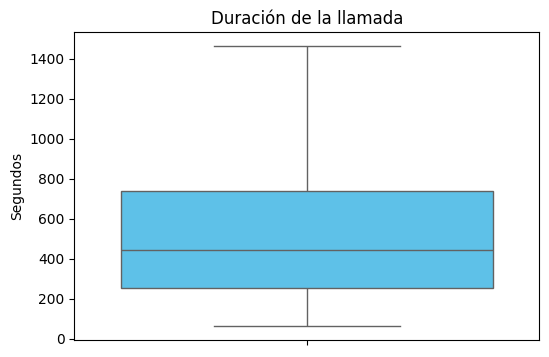

In [ ]:
# Escribe tu código aquí ⤵️

df_duration_c = df_si['duration'].copy()
df_duration_c[df_duration_c >= 1463] = 1463

conteo1 = (df_si['duration'] == 1463).sum()
print('Conteo SI', conteo1)
conteo2 = (df_duration_c == 1463).sum()
print('Conteo Capping', conteo2)

plt.figure(figsize=(6, 4))
sns.boxplot(y = df_duration_c, color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Duración de la llamada')
plt.ylabel('Segundos')
plt.show()

In [ ]:
# Calculo de cuartiles, rangos y porcentaje de outliers
# Escribe tu código aquí ⤵️

df_duration_c = pd.DataFrame(df_duration_c, columns=['duration'])

Q1 = df_duration_c['duration'].quantile(0.25)
Q2 = df_duration_c['duration'].quantile(0.50)
Q3 = df_duration_c['duration'].quantile(0.75)

print('Total registros: ',df_duration_c.shape[0])
print('Quartil 1: ', Q1)
print('Quartil 2: ', Q2)
print('Quartil 3: ', Q3)
print('El promedio es:', df_duration_c['duration'].mean())

RIC = Q3 - Q1
print('El rango intercuartílico de la variable "duration" es: ', RIC)

# Limites inferior y superior
lim_inferior = Q1 - 1.5 * RIC
lim_superior = Q3 + 1.5 * RIC

print('El límite inferior de las edades es: ', lim_inferior)
print('El límite superior de las edades es: ', lim_superior)

cant_out_inferior = df_duration_c[df_duration_c['duration'] < lim_inferior].shape[0]
print('La cantidad de outliers por debajo del límite inferior es: ', cant_out_inferior)

cant_out_superior = df_duration_c[df_duration_c['duration'] > lim_superior].shape[0]
print('La cantidad de outliers por encima del límite superior es: ', cant_out_superior)

porc_outliers = (cant_out_inferior + cant_out_superior) / df_duration_c.shape[0]
print('El total de outliers representa el', round(100*porc_outliers,2), '% del total de los datos')

cota_outliers = df_duration_c['duration'].quantile(1-round(porc_outliers,4))
print ('Los outliers se presentan a edades superiores a los ', cota_outliers, 'años')

Total registros:  4115
Quartil 1:  253.0
Quartil 2:  445.0
Quartil 3:  738.5
El promedio es: 539.5317132442284
El rango intercuartílico de la variable "duration" es:  485.5
El límite inferior de las edades es:  -475.25
El límite superior de las edades es:  1466.75
La cantidad de outliers por debajo del límite inferior es:  0
La cantidad de outliers por encima del límite superior es:  0
El total de outliers representa el 0.0 % del total de los datos
Los outliers se presentan a edades superiores a los  1463.0 años


🔁 Reemplazo en variable "duration"

En esta variable se reemplazarán los outliers por el valor correspondiente a la mediana.

Outliers antes del reemplazo 125
Conteo antes de reemplazar los outliers por la mediana 5
Conteo después de reemplazar los outliers por la mediana 130


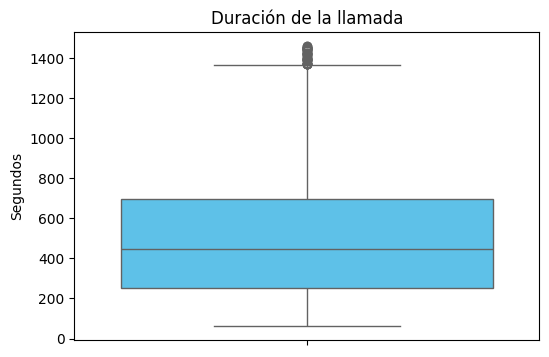

In [ ]:
# Escribe tu código aquí ⤵️

df_duration_m = df_si['duration'].copy()
df_duration_m[df_duration_m >= 1463] = 445

conteo1 = (df_si['duration'] >= 1463).sum()
print('Outliers antes del reemplazo', conteo1)
conteo2 = (df_si['duration'] == 445).sum()
print('Conteo antes de reemplazar los outliers por la mediana', conteo2)
conteo3 = (df_duration_m == 445).sum()
print('Conteo después de reemplazar los outliers por la mediana', conteo3)

plt.figure(figsize=(6, 4))
sns.boxplot(y = df_duration_m, color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Duración de la llamada')
plt.ylabel('Segundos')
plt.show()

In [ ]:
# Calculo de cuartiles, rangos y porcentaje de outliers
# Escribe tu código aquí ⤵️

df_duration_m = pd.DataFrame(df_duration_m, columns=['duration'])

Q1 = df_duration_m['duration'].quantile(0.25)
Q2 = df_duration_m['duration'].quantile(0.50)
Q3 = df_duration_m['duration'].quantile(0.75)

print('Total registros: ',df_duration_m.shape[0])
print('Quartil 1: ', Q1)
print('Quartil 2: ', Q2)
print('Quartil 3: ', Q3)
print('El promedio es:', df_duration_m['duration'].mean())

RIC = Q3 - Q1
print('El rango intercuartílico de la variable "duration" es: ', RIC)

# Limites inferior y superior
lim_inferior = Q1 - 1.5 * RIC
lim_superior = Q3 + 1.5 * RIC

print('El límite inferior de las edades es: ', lim_inferior)
print('El límite superior de las edades es: ', lim_superior)

cant_out_inferior = df_duration_m[df_duration_m['duration'] < lim_inferior].shape[0]
print('La cantidad de outliers por debajo del límite inferior es: ', cant_out_inferior)

cant_out_superior = df_duration_m[df_duration_m['duration'] > lim_superior].shape[0]
print('La cantidad de outliers por encima del límite superior es: ', cant_out_superior)

porc_outliers = (cant_out_inferior + cant_out_superior) / df_duration_m.shape[0]
print('El total de outliers representa el', round(100*porc_outliers,2), '% del total de los datos')

cota_outliers = df_duration_m['duration'].quantile(1-round(porc_outliers,4))
print ('Los outliers se presentan a edades superiores a los ', cota_outliers, 'años')

Total registros:  4115
Quartil 1:  253.0
Quartil 2:  445.0
Quartil 3:  699.0
El promedio es: 508.608262454435
El rango intercuartílico de la variable "duration" es:  446.0
El límite inferior de las edades es:  -416.0
El límite superior de las edades es:  1368.0
La cantidad de outliers por debajo del límite inferior es:  0
La cantidad de outliers por encima del límite superior es:  39
El total de outliers representa el 0.95 % del total de los datos
Los outliers se presentan a edades superiores a los  1364.8340000000017 años


✍🏼 Capping de la variable "campaign"

En esta etapa se reemplazarán los outliers por el valor donde empiezan a ocurrir.

Conteo SI 507
Conteo Capping 999


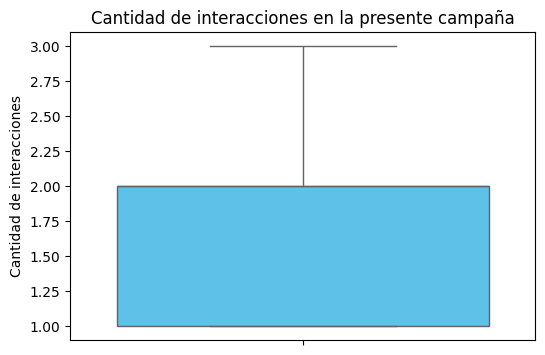

In [ ]:
# Escribe tu código aquí ⤵️

df_campaign_c = df_si['campaign'].copy()
df_campaign_c[df_campaign_c >= 3] = 3

conteo1 = (df_si['campaign'] == 3).sum()
print('Conteo SI', conteo1)
conteo2 = (df_campaign_c == 3).sum()
print('Conteo Capping', conteo2)

plt.figure(figsize=(6, 4))
sns.boxplot(y = df_campaign_c, color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Cantidad de interacciones en la presente campaña')
plt.ylabel('Cantidad de interacciones')
plt.show()

In [ ]:
# Calculo de cuartiles, rangos y porcentaje de outliers
# Escribe tu código aquí ⤵️

df_campaign_c = pd.DataFrame(df_campaign_c, columns=['campaign'])

Q1 = df_campaign_c['campaign'].quantile(0.25)
Q2 = df_campaign_c['campaign'].quantile(0.50)
Q3 = df_campaign_c['campaign'].quantile(0.75)

print('Total registros: ',df_campaign_c.shape[0])
print('Quartil 1: ', Q1)
print('Quartil 2: ', Q2)
print('Quartil 3: ', Q3)
print('El promedio es:', df_campaign_c['campaign'].mean())

RIC = Q3 - Q1
print('El rango intercuartílico de la variable "campaign" es: ', RIC)

# Limites inferior y superior
lim_inferior = Q1 - 1.5 * RIC
lim_superior = Q3 + 1.5 * RIC

print('El límite inferior de las edades es: ', lim_inferior)
print('El límite superior de las edades es: ', lim_superior)

cant_out_inferior = df_campaign_c[df_campaign_c['campaign'] < lim_inferior].shape[0]
print('La cantidad de outliers por debajo del límite inferior es: ', cant_out_inferior)

cant_out_superior = df_campaign_c[df_campaign_c['campaign'] > lim_superior].shape[0]
print('La cantidad de outliers por encima del límite superior es: ', cant_out_superior)

porc_outliers = (cant_out_inferior + cant_out_superior) / df_campaign_c.shape[0]
print('El total de outliers representa el', round(100*porc_outliers,2), '% del total de los datos')

cota_outliers = df_campaign_c['campaign'].quantile(1-round(porc_outliers,4))
print ('Los outliers se presentan a edades superiores a los ', cota_outliers, 'años')

Total registros:  4115
Quartil 1:  1.0
Quartil 2:  2.0
Quartil 3:  2.0
El promedio es: 1.7482381530984203
El rango intercuartílico de la variable "campaign" es:  1.0
El límite inferior de las edades es:  -0.5
El límite superior de las edades es:  3.5
La cantidad de outliers por debajo del límite inferior es:  0
La cantidad de outliers por encima del límite superior es:  0
El total de outliers representa el 0.0 % del total de los datos
Los outliers se presentan a edades superiores a los  3.0 años


🔁 Reemplazo en variable "campaign"

En esta variable se reemplazarán los outliers por el valor correspondiente a la mediana.

Outliers antes del reemplazo 999
Conteo antes de reemplazar los outliers por la mediana 1081
Conteo después de reemplazar los outliers por la mediana 2080


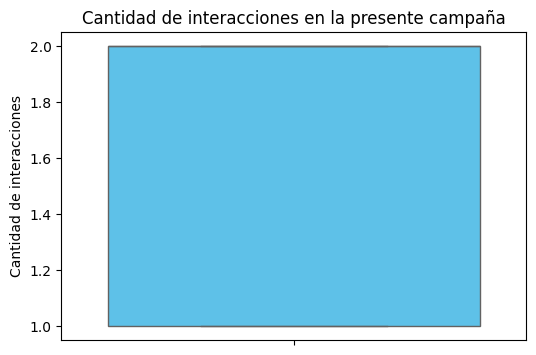

In [ ]:
# Escribe tu código aquí ⤵️

df_campaign_m = df_si['campaign'].copy()
df_campaign_m[df_campaign_m >= 3] = 2

conteo1 = (df_si['campaign'] >= 3).sum()
print('Outliers antes del reemplazo', conteo1)
conteo2 = (df_si['campaign'] == 2).sum()
print('Conteo antes de reemplazar los outliers por la mediana', conteo2)
conteo3 = (df_campaign_m == 2).sum()
print('Conteo después de reemplazar los outliers por la mediana', conteo3)

plt.figure(figsize=(6, 4))
sns.boxplot(y = df_campaign_m, color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Cantidad de interacciones en la presente campaña')
plt.ylabel('Cantidad de interacciones')
plt.show()

In [ ]:
# Calculo de cuartiles, rangos y porcentaje de outliers
# Escribe tu código aquí ⤵️

df_campaign_m = pd.DataFrame(df_campaign_m, columns=['campaign'])

Q1 = df_campaign_m['campaign'].quantile(0.25)
Q2 = df_campaign_m['campaign'].quantile(0.50)
Q3 = df_campaign_m['campaign'].quantile(0.75)

print('Total registros: ',df_campaign_m.shape[0])
print('Quartil 1: ', Q1)
print('Quartil 2: ', Q2)
print('Quartil 3: ', Q3)
print('El promedio es:', df_campaign_m['campaign'].mean())

RIC = Q3 - Q1
print('El rango intercuartílico de la variable "campaign" es: ', RIC)

# Limites inferior y superior
lim_inferior = Q1 - 1.5 * RIC
lim_superior = Q3 + 1.5 * RIC

print('El límite inferior de las edades es: ', lim_inferior)
print('El límite superior de las edades es: ', lim_superior)

cant_out_inferior = df_campaign_m[df_campaign_m['campaign'] < lim_inferior].shape[0]
print('La cantidad de outliers por debajo del límite inferior es: ', cant_out_inferior)

cant_out_superior = df_campaign_m[df_campaign_m['campaign'] > lim_superior].shape[0]
print('La cantidad de outliers por encima del límite superior es: ', cant_out_superior)

porc_outliers = (cant_out_inferior + cant_out_superior) / df_campaign_m.shape[0]
print('El total de outliers representa el', round(100*porc_outliers,2), '% del total de los datos')

cota_outliers = df_campaign_m['campaign'].quantile(1-round(porc_outliers,4))
print ('Los outliers se presentan a edades superiores a los ', cota_outliers, 'años')

Total registros:  4115
Quartil 1:  1.0
Quartil 2:  2.0
Quartil 3:  2.0
El promedio es: 1.50546780072904
El rango intercuartílico de la variable "campaign" es:  1.0
El límite inferior de las edades es:  -0.5
El límite superior de las edades es:  3.5
La cantidad de outliers por debajo del límite inferior es:  0
La cantidad de outliers por encima del límite superior es:  0
El total de outliers representa el 0.0 % del total de los datos
Los outliers se presentan a edades superiores a los  2.0 años


✍🏼 Capping de la variable "pdays"

En esta etapa se reemplazarán los outliers por el valor donde empiezan a ocurrir.

La cantidad de clientes que no han sido contactados previo a la presente campaña es:  3246
Esto representa el 78.88 % del total de los datos


<Axes: title={'center': 'Contacto previo a la campaña'}>

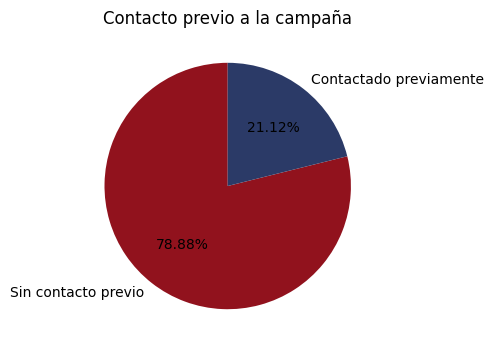

In [ ]:
# Calculamos el porcentaje de datos que representa el valor "999"
# Escribe tu código aquí ⤵️

sin_contacto_previo = df_si[df_si['pdays'] == 999].shape[0]
porcentaje_scp = round(100 * sin_contacto_previo / df_si.shape[0],2)
print('La cantidad de clientes que no han sido contactados previo a la presente campaña es: ', sin_contacto_previo)
print('Esto representa el', porcentaje_scp, '% del total de los datos')

contactado_previo = df_si[df_si['pdays'] != 999].shape[0]

leyendas = ['Sin contacto previo', 'Contactado previamente']
valores = [sin_contacto_previo, contactado_previo]
datos = {'Contacto': leyendas, 'Porcentaje':valores}
df_pdays_temp = pd.DataFrame(valores)

# Gráfico para establecer visualmente la segmentación

df_pdays_temp = pd.Series(
    valores,
    index=leyendas
)

df_pdays_temp.plot(
    kind='pie',
    autopct='%1.2f%%',
    colors=['#91121D', '#2B3A67'],
    startangle=90,
    figsize=(6,4),
    title='Contacto previo a la campaña',
    ylabel=''
)


Total de registros de clientes sin contacto previo:  869
Conteo outliers 26
Conteo Capping 133


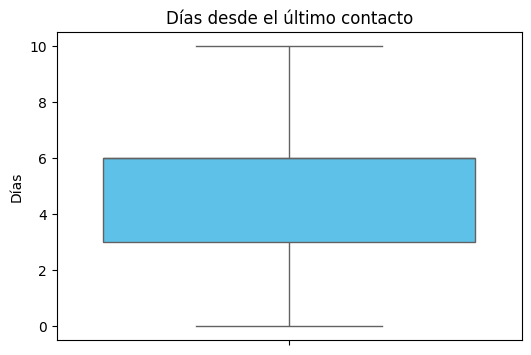

In [ ]:
# Escribe tu código aquí ⤵️

print('Total de registros de clientes sin contacto previo: ', df_temp.shape[0])

df_pdays_c = df_temp['pdays'].copy()
df_pdays_c[df_pdays_c >= 10] = 10

conteo1 = (df_temp['pdays'] == 10).sum()
print('Conteo outliers', conteo1)
conteo2 = (df_pdays_c == 10).sum()
print('Conteo Capping', conteo2)

plt.figure(figsize=(6, 4))
sns.boxplot(y = df_pdays_c, color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Días desde el último contacto')
plt.ylabel('Días')
plt.show()

In [ ]:
# Calculo de cuartiles, rangos y porcentaje de outliers
# Escribe tu código aquí ⤵️

df_pdays_c = pd.DataFrame(df_pdays_c, columns=['pdays'])

Q1 = df_pdays_c['pdays'].quantile(0.25)
Q2 = df_pdays_c['pdays'].quantile(0.50)
Q3 = df_pdays_c['pdays'].quantile(0.75)

print('Total registros: ',df_pdays_c.shape[0])
print('Quartil 1: ', Q1)
print('Quartil 2: ', Q2)
print('Quartil 3: ', Q3)
print('El promedio es:', df_pdays_c['pdays'].mean())

RIC = Q3 - Q1
print('El rango intercuartílico de la variable "pdays" es: ', RIC)

# Limites inferior y superior
lim_inferior = Q1 - 1.5 * RIC
lim_superior = Q3 + 1.5 * RIC

print('El límite inferior de las edades es: ', lim_inferior)
print('El límite superior de las edades es: ', lim_superior)

cant_out_inferior = df_pdays_c[df_pdays_c['pdays'] < lim_inferior].shape[0]
print('La cantidad de outliers por debajo del límite inferior es: ', cant_out_inferior)

cant_out_superior = df_pdays_c[df_pdays_c['pdays'] > lim_superior].shape[0]
print('La cantidad de outliers por encima del límite superior es: ', cant_out_superior)

porc_outliers = (cant_out_inferior + cant_out_superior) / df_pdays_c.shape[0]
print('El total de outliers representa el', round(100*porc_outliers,2), '% del total de los datos')

cota_outliers = df_pdays_c['pdays'].quantile(1-round(porc_outliers,4))
print ('Los outliers se presentan a edades superiores a los ', cota_outliers, 'años')

Total registros:  869
Quartil 1:  3.0
Quartil 2:  6.0
Quartil 3:  6.0
El promedio es: 5.46029919447641
El rango intercuartílico de la variable "pdays" es:  3.0
El límite inferior de las edades es:  -1.5
El límite superior de las edades es:  10.5
La cantidad de outliers por debajo del límite inferior es:  0
La cantidad de outliers por encima del límite superior es:  0
El total de outliers representa el 0.0 % del total de los datos
Los outliers se presentan a edades superiores a los  10.0 años


🔁 Reemplazo en variable "pdays"

En esta variable se reemplazarán los outliers por el valor correspondiente a la mediana.

Total de registros de clientes sin contacto previo:  869
Outliers antes del reemplazo:  133
Conteo antes de reemplazar los outliers por la mediana:  266
Conteo después de reemplazar los outliers por la mediana:  399


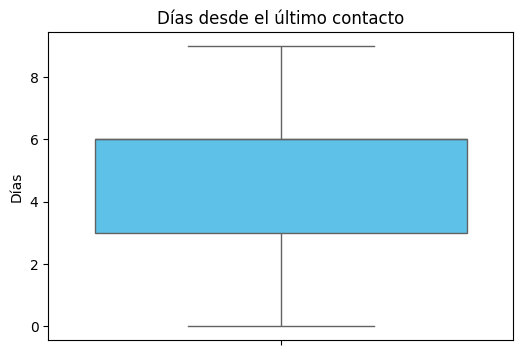

In [ ]:
# Escribe tu código aquí ⤵️

print('Total de registros de clientes sin contacto previo: ', df_temp.shape[0])

df_pdays_m = df_temp['pdays'].copy()
df_pdays_m[df_pdays_m >= 10] = 6

conteo1 = (df_temp['pdays'] >= 10).sum()
print('Outliers antes del reemplazo: ', conteo1)
conteo2 = (df_temp['pdays'] == 6).sum()
print('Conteo antes de reemplazar los outliers por la mediana: ', conteo2)
conteo3 = (df_pdays_m == 6).sum()
print('Conteo después de reemplazar los outliers por la mediana: ', conteo3)

plt.figure(figsize=(6, 4))
sns.boxplot(y = df_pdays_m, color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Días desde el último contacto')
plt.ylabel('Días')
plt.show()

In [ ]:
# Calculo de cuartiles, rangos y porcentaje de outliers
# Escribe tu código aquí ⤵️

df_pdays_m = pd.DataFrame(df_pdays_m, columns=['pdays'])

Q1 = df_pdays_m['pdays'].quantile(0.25)
Q2 = df_pdays_m['pdays'].quantile(0.50)
Q3 = df_pdays_m['pdays'].quantile(0.75)

print('Total registros: ',df_pdays_m.shape[0])
print('Quartil 1: ', Q1)
print('Quartil 2: ', Q2)
print('Quartil 3: ', Q3)
print('El promedio es:', df_pdays_m['pdays'].mean())

RIC = Q3 - Q1
print('El rango intercuartílico de la variable "pdays" es: ', RIC)

# Limites inferior y superior
lim_inferior = Q1 - 1.5 * RIC
lim_superior = Q3 + 1.5 * RIC

print('El límite inferior de las edades es: ', lim_inferior)
print('El límite superior de las edades es: ', lim_superior)

cant_out_inferior = df_pdays_m[df_pdays_m['pdays'] < lim_inferior].shape[0]
print('La cantidad de outliers por debajo del límite inferior es: ', cant_out_inferior)

cant_out_superior = df_pdays_m[df_pdays_m['pdays'] > lim_superior].shape[0]
print('La cantidad de outliers por encima del límite superior es: ', cant_out_superior)

porc_outliers = (cant_out_inferior + cant_out_superior) / df_pdays_m.shape[0]
print('El total de outliers representa el', round(100*porc_outliers,2), '% del total de los datos')

cota_outliers = df_pdays_m['pdays'].quantile(1-round(porc_outliers,4))
print ('Los outliers se presentan a edades superiores a los ', cota_outliers, 'años')

Total registros:  869
Quartil 1:  3.0
Quartil 2:  6.0
Quartil 3:  6.0
El promedio es: 4.848101265822785
El rango intercuartílico de la variable "pdays" es:  3.0
El límite inferior de las edades es:  -1.5
El límite superior de las edades es:  10.5
La cantidad de outliers por debajo del límite inferior es:  0
La cantidad de outliers por encima del límite superior es:  0
El total de outliers representa el 0.0 % del total de los datos
Los outliers se presentan a edades superiores a los  9.0 años


✍🏼 Capping de la variable "previous"

En esta etapa se reemplazarán los outliers por el valor donde empiezan a ocurrir.

Conteo SI 321
Conteo Capping 481


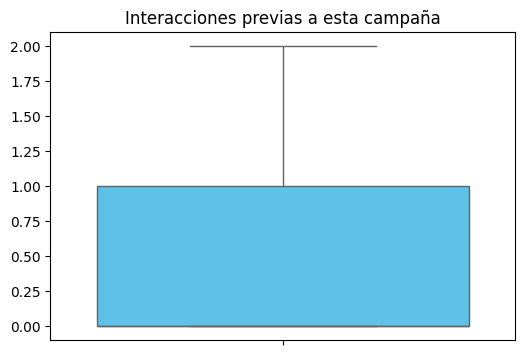

In [ ]:
# Escribe tu código aquí ⤵️

df_previous_c = df_si['previous'].copy()
df_previous_c[df_previous_c >= 2] = 2

conteo1 = (df_si['previous'] == 2).sum()
print('Conteo SI', conteo1)
conteo2 = (df_previous_c == 2).sum()
print('Conteo Capping', conteo2)


plt.figure(figsize=(6, 4))
sns.boxplot(y = df_previous_c, color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Interacciones previas a esta campaña')
plt.ylabel('')
plt.show()

In [ ]:
df_previous_c.head()

,previous
75,0
83,0
88,0
129,0
139,0


In [ ]:
# Calculo de cuartiles, rangos y porcentaje de outliers
# Escribe tu código aquí ⤵️

df_previous_c = pd.DataFrame(df_previous_c, columns=['previous'])
#df_previous_c.head()
Q1 = df_previous_c['previous'].quantile(0.25)
Q2 = df_previous_c['previous'].quantile(0.50)
Q3 = df_previous_c['previous'].quantile(0.75)

print('Total registros: ',df_previous_c.shape[0])
print('Quartil 1: ', Q1)
print('Quartil 2: ', Q2)
print('Quartil 3: ', Q3)
print('El promedio es:', df_previous_c['previous'].mean())

RIC = Q3 - Q1
print('El rango intercuartílico de la variable "previous" es: ', RIC)

# Limites inferior y superior
lim_inferior = Q1 - 1.5 * RIC
lim_superior = Q3 + 1.5 * RIC

print('El límite inferior de las edades es: ', lim_inferior)
print('El límite superior de las edades es: ', lim_superior)

cant_out_inferior = df_previous_c[df_previous_c['previous'] < lim_inferior].shape[0]
print('La cantidad de outliers por debajo del límite inferior es: ', cant_out_inferior)

cant_out_superior = df_previous_c[df_previous_c['previous'] > lim_superior].shape[0]
print('La cantidad de outliers por encima del límite superior es: ', cant_out_superior)

porc_outliers = (cant_out_inferior + cant_out_superior) / df_previous_c.shape[0]
print('El total de outliers representa el', round(100*porc_outliers,2), '% del total de los datos')

cota_outliers = df_previous_c['previous'].quantile(1-round(porc_outliers,4))
print ('Los outliers se presentan a edades superiores a los ', cota_outliers, 'años')

Total registros:  4115
Quartil 1:  0.0
Quartil 2:  0.0
Quartil 3:  1.0
El promedio es: 0.4439854191980559
El rango intercuartílico de la variable "previous" es:  1.0
El límite inferior de las edades es:  -1.5
El límite superior de las edades es:  2.5
La cantidad de outliers por debajo del límite inferior es:  0
La cantidad de outliers por encima del límite superior es:  0
El total de outliers representa el 0.0 % del total de los datos
Los outliers se presentan a edades superiores a los  2.0 años


🔁 Reemplazo en variable "pdays"

En esta variable se reemplazarán los outliers por el valor correspondiente a la mediana.

Outliers antes del reemplazo 481
Conteo antes de reemplazar los outliers por la mediana 2769
Conteo después de reemplazar los outliers por la mediana 3250


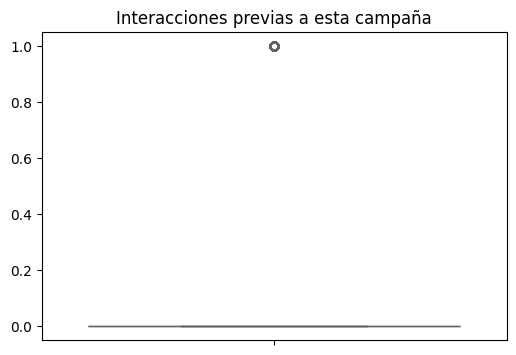

In [ ]:
# Escribe tu código aquí ⤵️

df_previous_m = df_si['previous'].copy()
df_previous_m[df_previous_m >= 2] = 0

conteo1 = (df_si['previous'] >= 2).sum()
print('Outliers antes del reemplazo', conteo1)
conteo2 = (df_si['previous'] == 0).sum()
print('Conteo antes de reemplazar los outliers por la mediana', conteo2)
conteo3 = (df_previous_m == 0).sum()
print('Conteo después de reemplazar los outliers por la mediana', conteo3)

plt.figure(figsize=(6, 4))
sns.boxplot(y = df_previous_m, color ='#47CBFF') # 'y=' para vertical, 'x=' para horizontal
plt.title('Interacciones previas a esta campaña')
plt.ylabel('')
plt.show()

In [ ]:
# Calculo de cuartiles, rangos y porcentaje de outliers
# Escribe tu código aquí ⤵️

df_previous_m = pd.DataFrame(df_previous_m, columns=['previous'])

Q1 = df_previous_m['previous'].quantile(0.25)
Q2 = df_previous_m['previous'].quantile(0.50)
Q3 = df_previous_m['previous'].quantile(0.75)

print('Total registros: ',df_previous_m.shape[0])
print('Quartil 1: ', Q1)
print('Quartil 2: ', Q2)
print('Quartil 3: ', Q3)
print('El promedio es:', df_previous_m['previous'].mean())

RIC = Q3 - Q1
print('El rango intercuartílico de la variable "previous" es: ', RIC)

# Limites inferior y superior
lim_inferior = Q1 - 1.5 * RIC
lim_superior = Q3 + 1.5 * RIC

print('El límite inferior de las edades es: ', lim_inferior)
print('El límite superior de las edades es: ', lim_superior)

cant_out_inferior = df_previous_m[df_previous_m['previous'] < lim_inferior].shape[0]
print('La cantidad de outliers por debajo del límite inferior es: ', cant_out_inferior)

cant_out_superior = df_previous_m[df_previous_m['previous'] > lim_superior].shape[0]
print('La cantidad de outliers por encima del límite superior es: ', cant_out_superior)

porc_outliers = (cant_out_inferior + cant_out_superior) / df_previous_m.shape[0]
print('El total de outliers representa el', round(100*porc_outliers,2), '% del total de los datos')

cota_outliers = df_previous_m['previous'].quantile(1-round(porc_outliers,4))
print ('Los outliers se presentan a edades superiores a los ', cota_outliers, 'años')

Total registros:  4115
Quartil 1:  0.0
Quartil 2:  0.0
Quartil 3:  0.0
El promedio es: 0.21020656136087484
El rango intercuartílico de la variable "previous" es:  0.0
El límite inferior de las edades es:  0.0
El límite superior de las edades es:  0.0
La cantidad de outliers por debajo del límite inferior es:  0
La cantidad de outliers por encima del límite superior es:  865
El total de outliers representa el 21.02 % del total de los datos
Los outliers se presentan a edades superiores a los  0.23720000000002983 años


In [ ]:
# Se realiza Capping como método de imputación a todas las variables numéricas
# Escribe tu código aquí ⤵️

df_final = df_si.copy()
df_final.loc[df_final['age'] >= 78, 'age'] = 78
df_final.loc[df_final['duration'] >= 1463, 'duration'] = 1463
df_final.loc[df_final['campaign'] >= 3, 'campaign'] = 3
df_final.loc[df_final['pdays'].isin([10,11,12,13,14,15,16,17,18,19,21,22,25,26,27]), 'pdays'] = 10
df_final.loc[df_final['previous'] >= 2, 'previous'] = 2
df_final = df_final.drop ('Unnamed: 0', axis = 1)
df_final.reset_index(drop=True, inplace=True)
print('Total registros: ', df_final.shape[0])

df_final.head()

Total registros:  4115


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,41.0,blue-collar,divorced,basic.4y,unknown,yes,no,telephone,may,mon,1463.0,1,999,0,nonexistent,yes
1,49.0,entrepreneur,married,university.degree,unknown,yes,no,telephone,may,mon,1042.0,1,999,0,nonexistent,yes
2,49.0,technician,married,basic.9y,no,no,no,telephone,may,mon,1463.0,1,999,0,nonexistent,yes
3,41.0,technician,married,professional.course,unknown,yes,no,telephone,may,mon,579.0,1,999,0,nonexistent,yes
4,45.0,blue-collar,married,basic.9y,unknown,yes,no,telephone,may,mon,461.0,1,999,0,nonexistent,yes


In [ ]:
# Se exporta el dataset final
# Escribe tu código aquí ⤵️

df_final.to_csv('df_final.csv')
df_final.to_excel('df_final.xlsx')
